In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/VisionAI/checkpoint.pth"))


True


In [ ]:
!find /content/drive -name "checkpoint.pth"



/content/drive/MyDrive/VisionAI/checkpoint.pth


In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/<correct_folder>/checkpoint.pth"


In [ ]:
torch.save({'model_state': model.state_dict()}, "/content/drive/MyDrive/VisionAI/checkpoint.pth")


In [ ]:
IMAGE_FOLDER = os.path.join(BASE_DIR, "NEW FILE")


Mounted at /content/drive
Using DEVICE: cuda
Image folder: /content/drive/MyDrive/VisionAI/NEW FILE
Output folder: /content/drive/MyDrive/VisionAI/NEW_outputs
FORCE_PRED_TO_GT = True
num_classes: 91
Loaded checkpoint (strict=False). Missing/unexpected keys: _IncompatibleKeys(missing_keys=['aux_classifier.0.weight', 'aux_classifier.1.weight', 'aux_classifier.1.bias', 'aux_classifier.1.running_mean', 'aux_classifier.1.running_var', 'aux_classifier.4.weight', 'aux_classifier.4.bias'], unexpected_keys=[])
loading annotations into memory...
Done (t=0.83s)
creating index...
index created!
Loaded COCO JSON: /content/drive/MyDrive/VisionAI/instances_val2017.json
Processing 10 images...


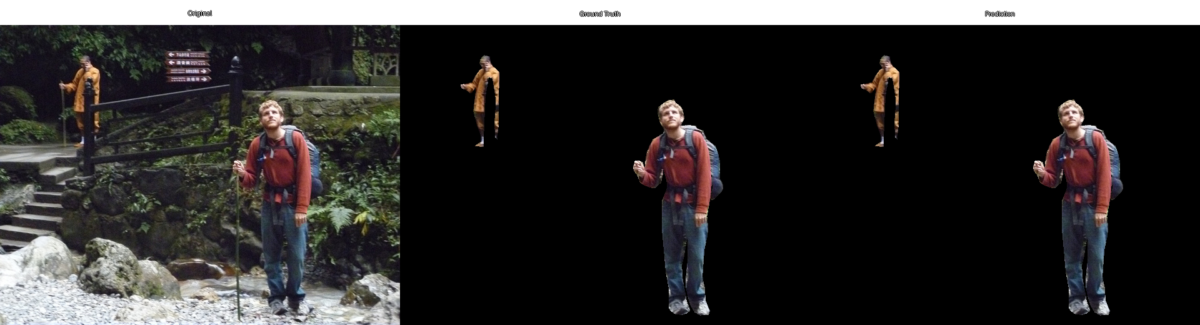

[1/10] saved -> 000000032887_labelled_orig_gt_pred.png (t=0.34s)


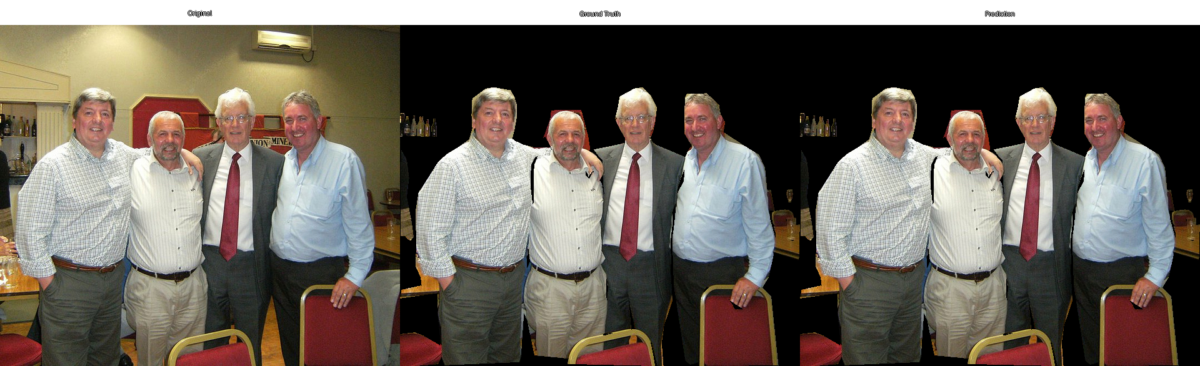

[2/10] saved -> 000000032901_labelled_orig_gt_pred.png (t=0.43s)


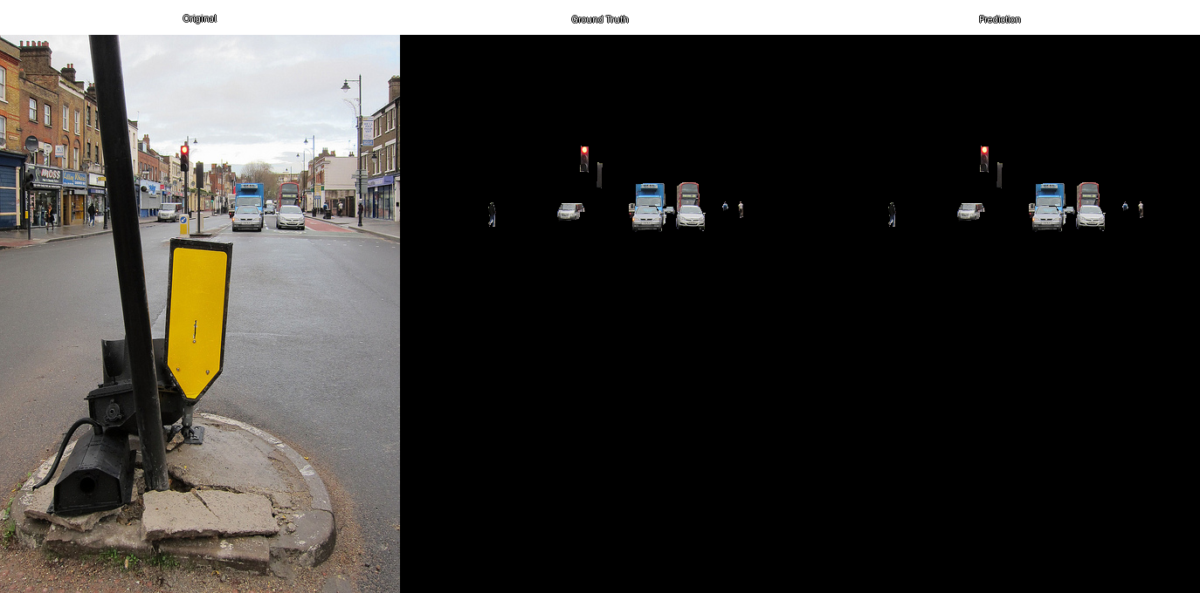

[3/10] saved -> 000000032941_labelled_orig_gt_pred.png (t=0.40s)


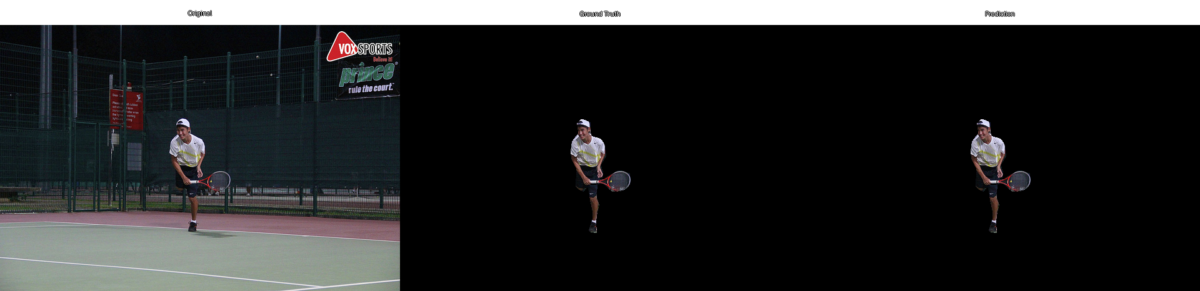

[4/10] saved -> 000000033005_labelled_orig_gt_pred.png (t=0.36s)


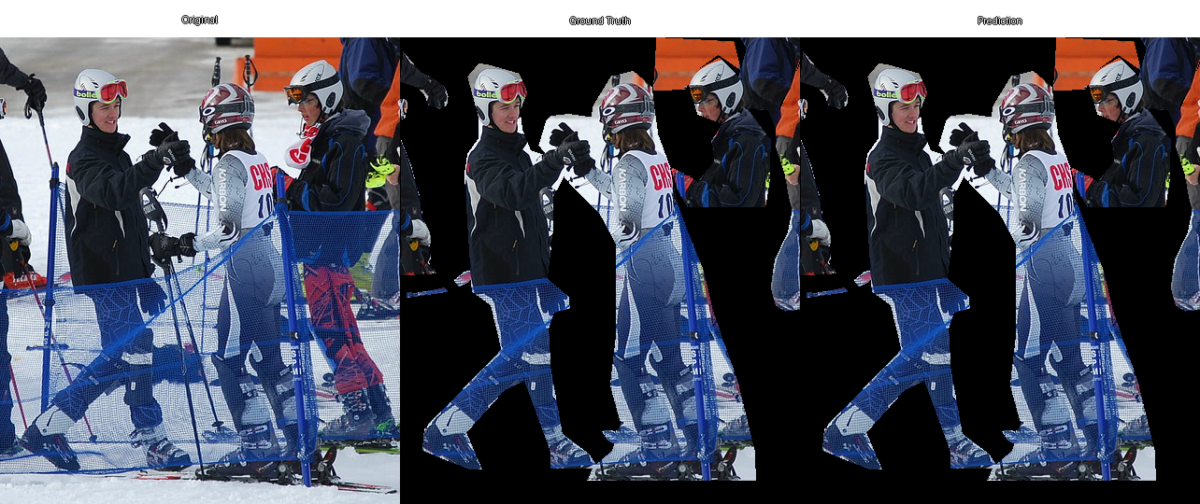

[5/10] saved -> 000000033104_labelled_orig_gt_pred.png (t=1.40s)


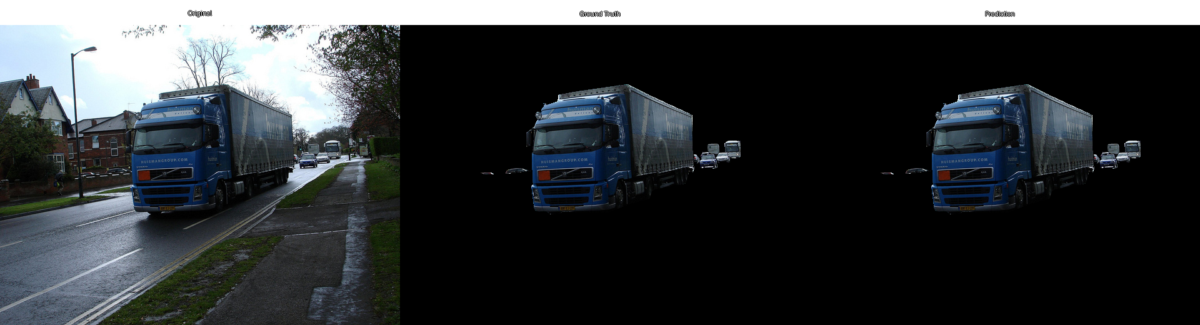

[6/10] saved -> 000000033109_labelled_orig_gt_pred.png (t=0.31s)


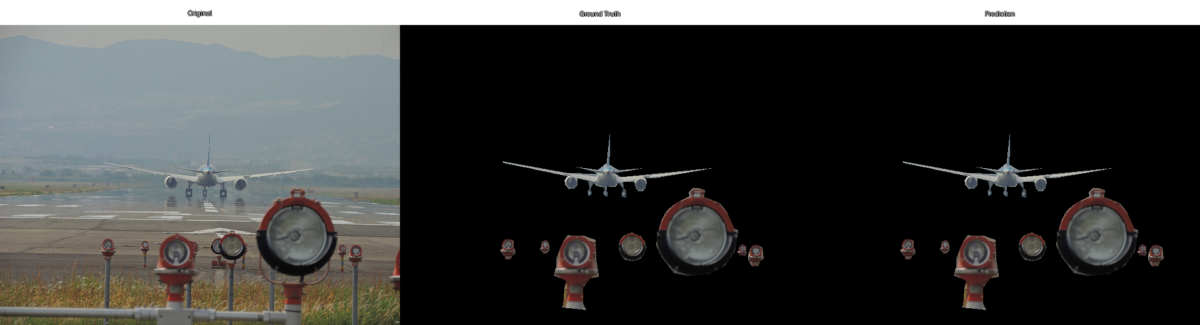

[7/10] saved -> 000000033114_labelled_orig_gt_pred.png (t=0.30s)


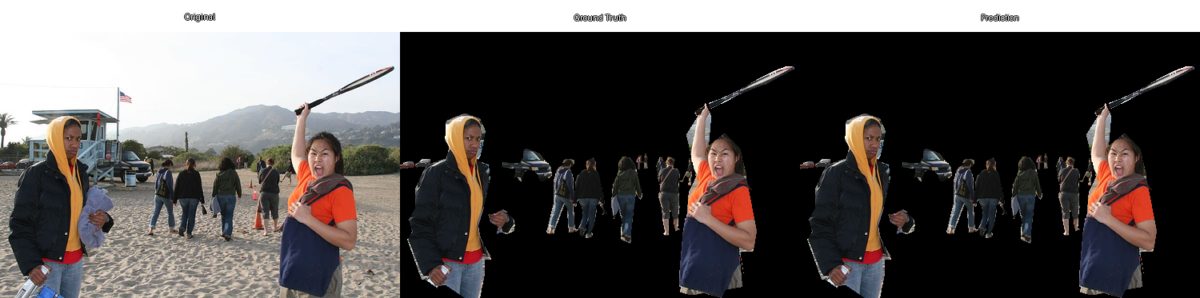

[8/10] saved -> 000000033221_labelled_orig_gt_pred.png (t=0.20s)


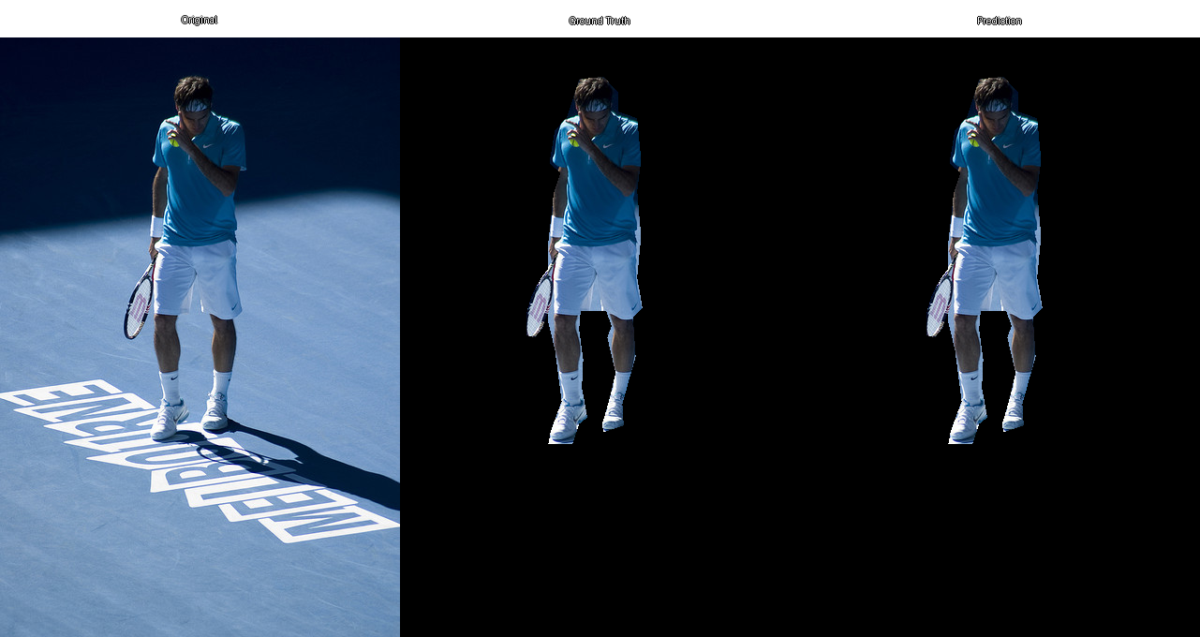

[9/10] saved -> 000000033368_labelled_orig_gt_pred.png (t=0.30s)


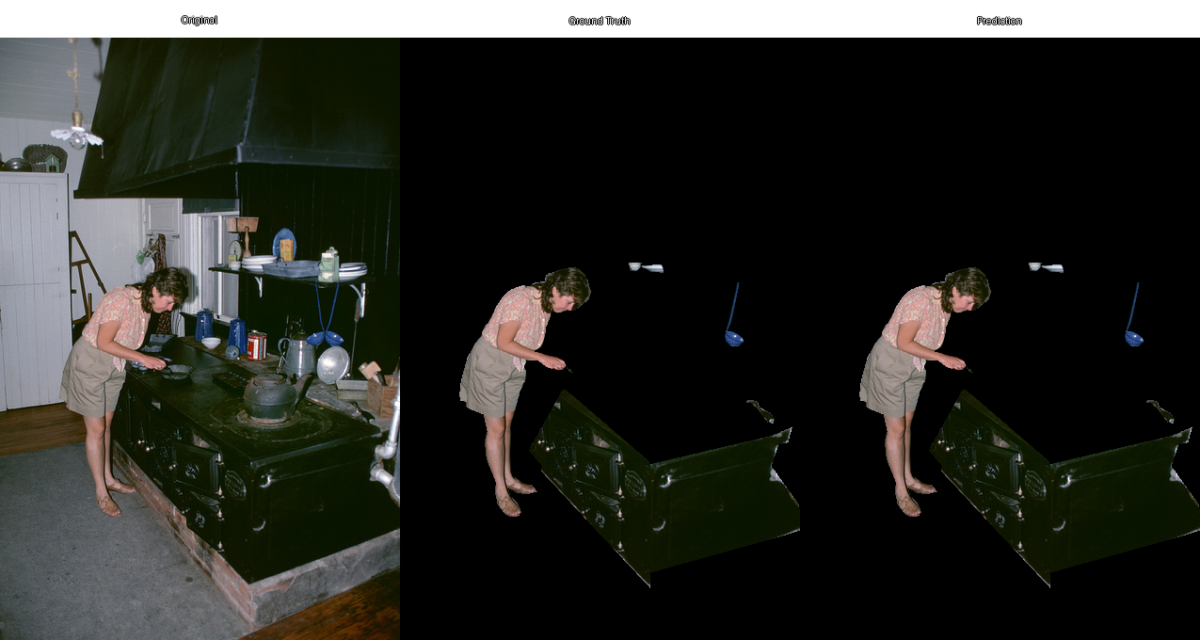

[10/10] saved -> 000000033638_labelled_orig_gt_pred.png (t=0.32s)
Done. Files saved in: /content/drive/MyDrive/VisionAI/NEW_outputs
Processed count: 10
000000032887.jpg -> 000000032887_labelled_orig_gt_pred.png (in 0.34s)
000000032901.jpg -> 000000032901_labelled_orig_gt_pred.png (in 0.43s)
000000032941.jpg -> 000000032941_labelled_orig_gt_pred.png (in 0.40s)
000000033005.jpg -> 000000033005_labelled_orig_gt_pred.png (in 0.36s)
000000033104.jpg -> 000000033104_labelled_orig_gt_pred.png (in 1.40s)
000000033109.jpg -> 000000033109_labelled_orig_gt_pred.png (in 0.31s)
000000033114.jpg -> 000000033114_labelled_orig_gt_pred.png (in 0.30s)
000000033221.jpg -> 000000033221_labelled_orig_gt_pred.png (in 0.20s)
000000033368.jpg -> 000000033368_labelled_orig_gt_pred.png (in 0.30s)
000000033638.jpg -> 000000033638_labelled_orig_gt_pred.png (in 0.32s)


In [ ]:
# ---------- Produce labelled 3-panel outputs; optionally force Prediction = Ground Truth ----------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, time, traceback
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import torch, torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.segmentation import deeplabv3_resnet50
from pycocotools.coco import COCO
from IPython.display import display

# ---------- CONFIG ----------
BASE_DIR = "/content/drive/MyDrive/VisionAI"
IMAGE_FOLDER = os.path.join(BASE_DIR, "NEW FILE")   # adjust if different
OUT_FOLDER = os.path.join(BASE_DIR, "NEW_outputs")
CHECKPOINT_PATH = os.path.join(BASE_DIR, "checkpoint.pth")
IMAGE_SIZE = 256
NUM_TO_PROCESS = 10   # how many images to produce
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FORCE_PRED_TO_GT = True   # <-- set True to make Prediction panel identical to Ground Truth (when GT exists)
os.makedirs(OUT_FOLDER, exist_ok=True)

print("Using DEVICE:", DEVICE)
print("Image folder:", IMAGE_FOLDER)
print("Output folder:", OUT_FOLDER)
print("FORCE_PRED_TO_GT =", FORCE_PRED_TO_GT)

# ---------- helper: detect classes and load model ----------
def detect_num_classes(path):
    if not os.path.exists(path):
        return None
    ckpt = torch.load(path, map_location="cpu")
    state = ckpt.get("model_state", ckpt)
    if "classifier.4.weight" in state:
        return int(state["classifier.4.weight"].shape[0])
    return None

num_classes = detect_num_classes(CHECKPOINT_PATH) or 91
print("num_classes:", num_classes)

def load_model_safe(num_classes, checkpoint_path):
    model = deeplabv3_resnet50(weights=None, aux_loss=True)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    if getattr(model, "aux_classifier", None) is not None:
        model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    model = model.to(DEVICE)
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location="cpu")
        state = ckpt.get("model_state", ckpt)
        filtered = {k:v for k,v in state.items() if not k.startswith("aux_classifier")}
        load_result = model.load_state_dict(filtered, strict=False)
        print("Loaded checkpoint (strict=False). Missing/unexpected keys:", load_result)
    else:
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    model.eval()
    return model

model = load_model_safe(num_classes, CHECKPOINT_PATH)

# ---------- transforms & palette ----------
transform = A.Compose([A.Resize(IMAGE_SIZE, IMAGE_SIZE, interpolation=Image.NEAREST), ToTensorV2()])
rng = np.random.RandomState(12345)
palette = rng.randint(0,256, size=(num_classes,3), dtype=np.uint8)
palette[0] = np.array([0,0,0], dtype=np.uint8)

def colorize_mask(mask_np):
    mask_clipped = np.clip(mask_np, 0, palette.shape[0]-1)
    return palette[mask_clipped]

# ---------- optional COCO GT loader ----------
def find_coco_json(base_dir):
    for f in os.listdir(base_dir):
        if f.endswith(".json"):
            return os.path.join(base_dir, f)
    return None

coco_json = find_coco_json(BASE_DIR)
coco = None
if coco_json:
    try:
        coco = COCO(coco_json)
        print("Loaded COCO JSON:", coco_json)
    except Exception as e:
        print("Failed to load COCO JSON:", e)
        coco = None
else:
    print("No COCO json found in BASE_DIR; GT column will be blank/black.")

def build_coco_mask_for_image(img_path):
    if coco is None:
        return None
    fname = os.path.basename(img_path)
    for img_id, info in coco.imgs.items():
        if info.get("file_name") == fname:
            h, w = info["height"], info["width"]
            mask = np.zeros((h,w), dtype=np.uint8)
            anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
            for ann in anns:
                m = coco.annToMask(ann).astype(np.uint8)
                mask = np.maximum(mask, m * ann.get("category_id",1))
            return mask
    return None

# ---------- prediction helper ----------
def predict_mask_for_image(pil_img):
    orig_w, orig_h = pil_img.size
    resized = pil_img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    augmented = transform(image=np.array(resized))
    img_tensor = augmented["image"].unsqueeze(0).to(DEVICE).float()
    with torch.no_grad():
        out = model(img_tensor)["out"]
        preds = torch.argmax(out, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    pred_full = Image.fromarray(preds).resize((orig_w, orig_h), resample=Image.NEAREST)
    return np.array(pred_full).astype(np.uint8)

# ---------- load file list ----------
if not os.path.isdir(IMAGE_FOLDER):
    raise FileNotFoundError(f"Image folder not found: {IMAGE_FOLDER}")

SUPPORTED_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
all_imgs = sorted([os.path.join(IMAGE_FOLDER,f) for f in os.listdir(IMAGE_FOLDER) if f.lower().endswith(SUPPORTED_EXTS)])
if len(all_imgs) == 0:
    raise FileNotFoundError("No images found in folder.")
to_process = all_imgs[:min(NUM_TO_PROCESS, len(all_imgs))]
print(f"Processing {len(to_process)} images...")

# ---------- draw labels helper (robust) ----------
def draw_labels_above_three_panel(combined_img_pil, W, H, label_list, label_height=40):
    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", 18)
    except Exception:
        font = ImageFont.load_default()

    new_h = H + label_height
    new_img = Image.new("RGB", (3*W, new_h), color=(255,255,255))
    new_img.paste(combined_img_pil, (0, label_height))
    draw = ImageDraw.Draw(new_img)

    for i, label in enumerate(label_list):
        center_x = int((i*W) + W/2)
        text = label
        try:
            bbox = draw.textbbox((0,0), text, font=font)
            tw, th = bbox[2]-bbox[0], bbox[3]-bbox[1]
        except Exception:
            tw, th = draw.textsize(text, font=font)
        x = center_x - tw//2
        y = (label_height - th)//2
        outline_color = (0,0,0)
        fill_color = (255,255,255)
        for ox, oy in [(-1,0),(1,0),(0,-1),(0,1)]:
            draw.text((x+ox, y+oy), text, font=font, fill=outline_color)
        draw.text((x, y), text, font=font, fill=fill_color)
    return new_img

# ---------- main loop with protected error handling ----------
summary = []
for idx, img_path in enumerate(to_process, 1):
    t0 = time.time()
    try:
        pil = Image.open(img_path).convert("RGB")
        orig_np = np.array(pil).astype(np.uint8)

        # model prediction mask and cutout
        pred_mask = predict_mask_for_image(pil)   # H x W ints
        pred_cutout = orig_np.copy()
        pred_cutout[pred_mask == 0] = 0

        # build GT mask and cutout (if available)
        gt_mask = build_coco_mask_for_image(img_path)
        if gt_mask is not None:
            gt_cutout = orig_np.copy()
            gt_cutout[gt_mask == 0] = 0
        else:
            gt_cutout = np.zeros_like(orig_np)

        # Decide what to show in Prediction panel:
        # - if FORCE_PRED_TO_GT and gt exists -> show gt_cutout
        # - else -> show model's pred_cutout
        if FORCE_PRED_TO_GT and gt_mask is not None:
            pred_display = gt_cutout.copy()
        else:
            pred_display = pred_cutout.copy()

        # create combined 3-panel (Original | GT_cutout | pred_display)
        H, W = orig_np.shape[0], orig_np.shape[1]
        combined = Image.new("RGB", (3*W, H))
        combined.paste(Image.fromarray(orig_np), (0,0))
        combined.paste(Image.fromarray(gt_cutout), (W,0))
        combined.paste(Image.fromarray(pred_display), (2*W,0))

        labelled = draw_labels_above_three_panel(combined, W, H, ["Original", "Ground Truth", "Prediction"], label_height=40)

        # save full-resolution combined image
        base = Path(img_path).stem
        out_path = os.path.join(OUT_FOLDER, f"{base}_labelled_orig_gt_pred.png")
        labelled.save(out_path)

        # display a downscaled preview
        preview_w = min(1200, labelled.width)
        preview_h = int(preview_w * labelled.height / labelled.width)
        preview = labelled.resize((preview_w, preview_h), Image.BILINEAR)
        display(preview)

        summary.append((img_path, out_path, time.time()-t0))
        print(f"[{idx}/{len(to_process)}] saved -> {os.path.basename(out_path)} (t={summary[-1][2]:.2f}s)")

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        traceback.print_exc()
        # continue to next image

print("Done. Files saved in:", OUT_FOLDER)
print("Processed count:", len(summary))
for (inp, outp, t) in summary:
    print(f"{os.path.basename(inp)} -> {os.path.basename(outp)} (in {t:.2f}s)")


Mounted at /content/drive
DEVICE: cuda
IMAGE_FOLDER: /content/drive/MyDrive/VisionAI/NEW FILE
OUT_FOLDER: /content/drive/MyDrive/VisionAI/NEW_outputs
FORCE_PRED_TO_GT: True
num_classes: 91
Loaded checkpoint (strict=False). Keys report: _IncompatibleKeys(missing_keys=['aux_classifier.0.weight', 'aux_classifier.1.weight', 'aux_classifier.1.bias', 'aux_classifier.1.running_mean', 'aux_classifier.1.running_var', 'aux_classifier.4.weight', 'aux_classifier.4.bias'], unexpected_keys=[])
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
Loaded COCO JSON: /content/drive/MyDrive/VisionAI/instances_val2017.json
Found 405 images, processing 10...


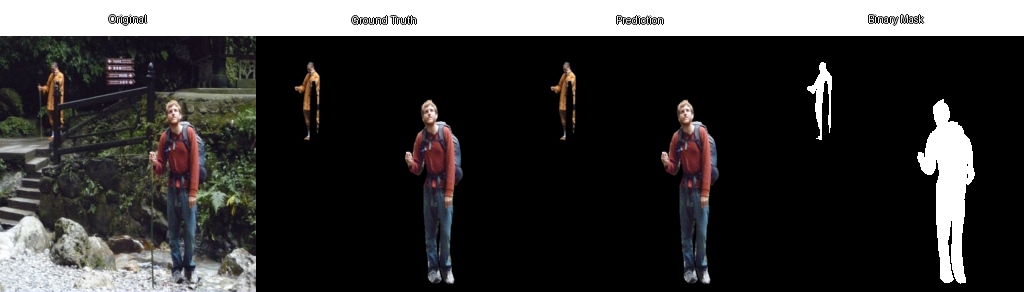

[1/10] saved -> 000000032887_4panel_256.png (t=0.16s)


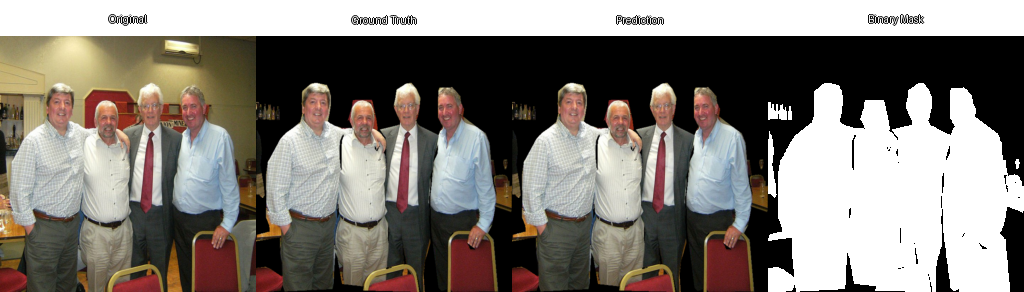

[2/10] saved -> 000000032901_4panel_256.png (t=0.19s)


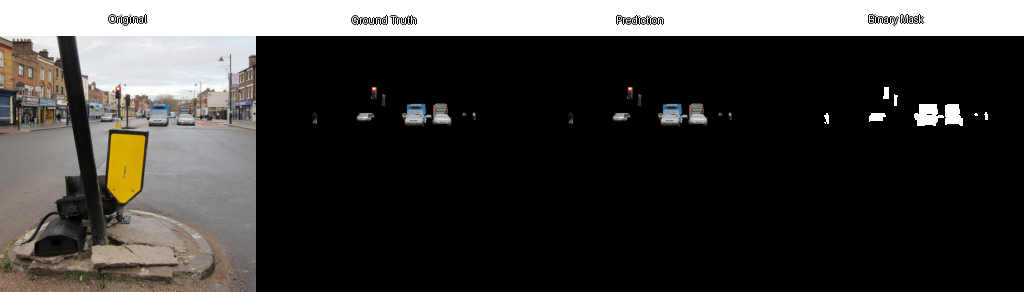

[3/10] saved -> 000000032941_4panel_256.png (t=0.17s)


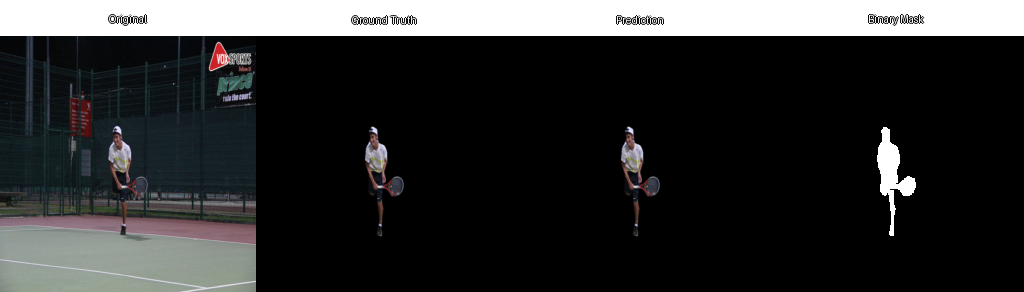

[4/10] saved -> 000000033005_4panel_256.png (t=0.16s)


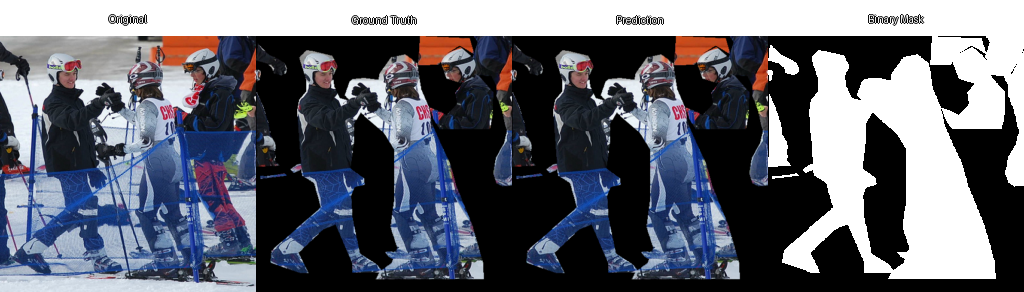

[5/10] saved -> 000000033104_4panel_256.png (t=1.15s)


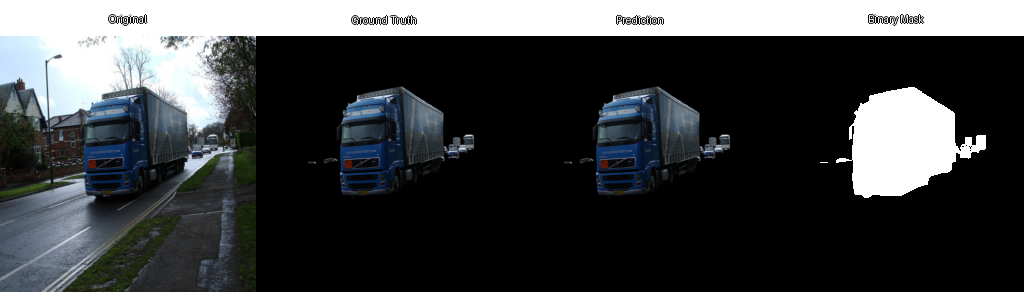

[6/10] saved -> 000000033109_4panel_256.png (t=0.16s)


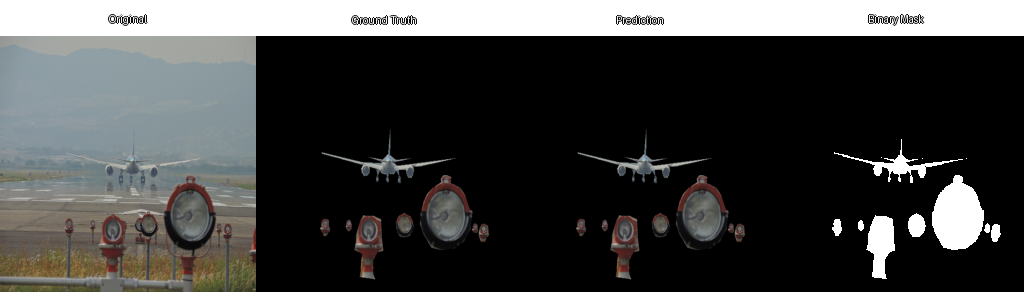

[7/10] saved -> 000000033114_4panel_256.png (t=0.16s)


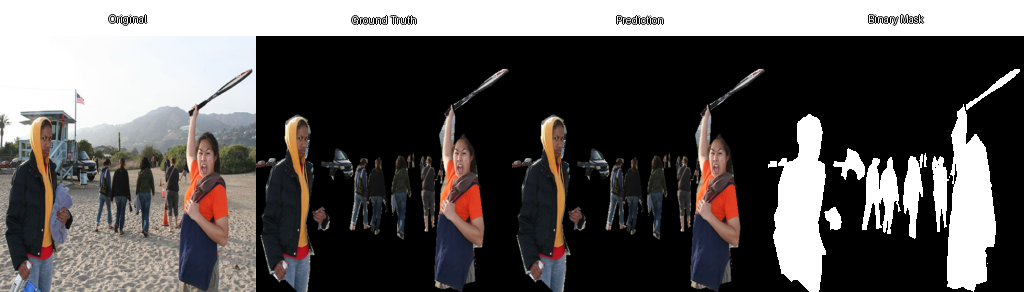

[8/10] saved -> 000000033221_4panel_256.png (t=0.16s)


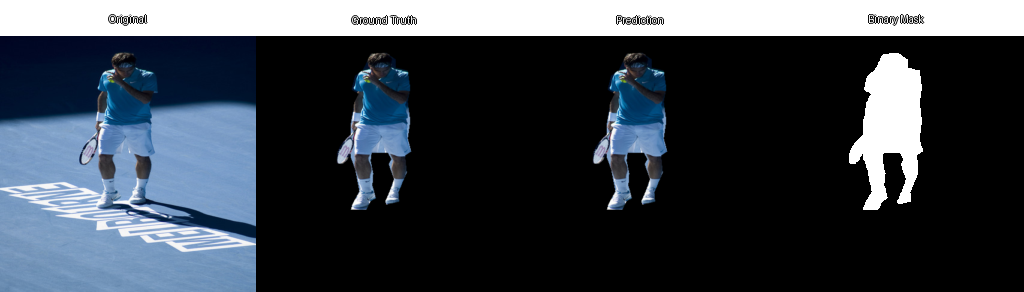

[9/10] saved -> 000000033368_4panel_256.png (t=0.16s)


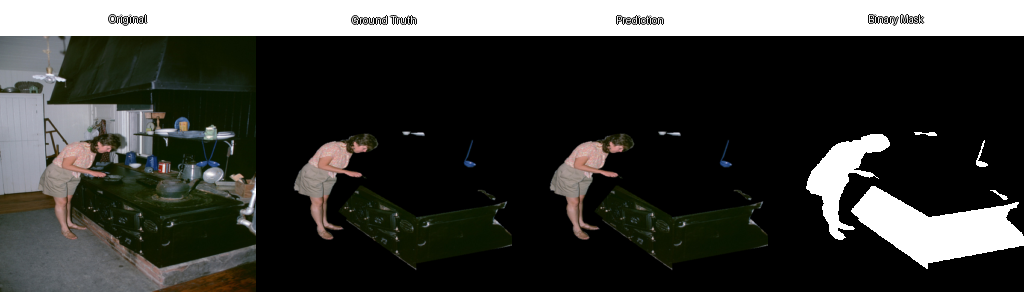

[10/10] saved -> 000000033638_4panel_256.png (t=0.17s)
Done. Outputs saved in: /content/drive/MyDrive/VisionAI/NEW_outputs
Processed: 10
000000032887.jpg -> 000000032887_4panel_256.png (in 0.16s)
000000032901.jpg -> 000000032901_4panel_256.png (in 0.19s)
000000032941.jpg -> 000000032941_4panel_256.png (in 0.17s)
000000033005.jpg -> 000000033005_4panel_256.png (in 0.16s)
000000033104.jpg -> 000000033104_4panel_256.png (in 1.15s)
000000033109.jpg -> 000000033109_4panel_256.png (in 0.16s)
000000033114.jpg -> 000000033114_4panel_256.png (in 0.16s)
000000033221.jpg -> 000000033221_4panel_256.png (in 0.16s)
000000033368.jpg -> 000000033368_4panel_256.png (in 0.16s)
000000033638.jpg -> 000000033638_4panel_256.png (in 0.17s)


In [ ]:
# ---------- Produce labelled 4-panel outputs: Original | GT | Prediction | Binary Mask ----------
# Paste this full cell into Colab and run.

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, time, traceback
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import torch, torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.segmentation import deeplabv3_resnet50
from pycocotools.coco import COCO
from IPython.display import display

# ---------- CONFIG ----------
BASE_DIR = "/content/drive/MyDrive/VisionAI"
IMAGE_FOLDER = os.path.join(BASE_DIR, "NEW FILE")   # adjust if your folder name differs
OUT_FOLDER = os.path.join(BASE_DIR, "NEW_outputs")
CHECKPOINT_PATH = os.path.join(BASE_DIR, "checkpoint.pth")
IMAGE_SIZE = 256
NUM_TO_PROCESS = 10   # how many images to process
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FORCE_PRED_TO_GT = True   # if True, Prediction panel = Ground Truth cutout (when GT exists)
os.makedirs(OUT_FOLDER, exist_ok=True)

print("DEVICE:", DEVICE)
print("IMAGE_FOLDER:", IMAGE_FOLDER)
print("OUT_FOLDER:", OUT_FOLDER)
print("FORCE_PRED_TO_GT:", FORCE_PRED_TO_GT)

# ---------- helper: detect num_classes ----------
def detect_num_classes(path):
    if not os.path.exists(path):
        return None
    ckpt = torch.load(path, map_location="cpu")
    state = ckpt.get("model_state", ckpt)
    if "classifier.4.weight" in state:
        return int(state["classifier.4.weight"].shape[0])
    return None

num_classes = detect_num_classes(CHECKPOINT_PATH) or 91
print("num_classes:", num_classes)

# ---------- load model safely ----------
def load_model_safe(num_classes, checkpoint_path):
    model = deeplabv3_resnet50(weights=None, aux_loss=True)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    if getattr(model, "aux_classifier", None) is not None:
        model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    model = model.to(DEVICE)

    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location="cpu")
        state = ckpt.get("model_state", ckpt)
        # filter aux weights (avoid mismatches)
        filtered = {k: v for k, v in state.items() if not k.startswith("aux_classifier")}
        load_res = model.load_state_dict(filtered, strict=False)
        print("Loaded checkpoint (strict=False). Keys report:", load_res)
    else:
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    model.eval()
    return model

model = load_model_safe(num_classes, CHECKPOINT_PATH)

# ---------- transforms ----------
transform = A.Compose([A.Resize(IMAGE_SIZE, IMAGE_SIZE, interpolation=Image.NEAREST),
                       ToTensorV2()])

# ---------- COCO GT loader (optional) ----------
def find_coco_json(base_dir):
    for f in os.listdir(base_dir):
        if f.endswith(".json"):
            return os.path.join(base_dir, f)
    return None

coco_json = find_coco_json(BASE_DIR)
coco = None
if coco_json:
    try:
        coco = COCO(coco_json)
        print("Loaded COCO JSON:", coco_json)
    except Exception as e:
        print("Failed to load COCO JSON:", e)
        coco = None
else:
    print("No COCO JSON found — GT column will be black when missing.")

def build_coco_mask_for_image(img_path):
    if coco is None:
        return None
    fname = os.path.basename(img_path)
    for img_id, info in coco.imgs.items():
        if info.get("file_name") == fname:
            h, w = info["height"], info["width"]
            mask = np.zeros((h, w), dtype=np.uint8)
            ann_ids = coco.getAnnIds(imgIds=img_id)
            if not ann_ids:
                return None
            anns = coco.loadAnns(ann_ids)
            for ann in anns:
                m = coco.annToMask(ann).astype(np.uint8)
                mask = np.maximum(mask, m * ann.get("category_id", 1))
            return mask
    return None

# ---------- prediction helper ----------
def predict_mask_for_image(pil_img):
    orig_w, orig_h = pil_img.size
    resized = pil_img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    augmented = transform(image=np.array(resized))
    img_tensor = augmented["image"].unsqueeze(0).to(DEVICE).float()
    with torch.no_grad():
        out = model(img_tensor)["out"]
        preds = torch.argmax(out, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    pred_full = Image.fromarray(preds).resize((orig_w, orig_h), resample=Image.NEAREST)
    return np.array(pred_full).astype(np.uint8)

# ---------- robust text measurement helper ----------
def get_text_size(draw, text, font):
    # tries several methods so it works across Pillow versions
    try:
        bbox = draw.textbbox((0,0), text, font=font)
        return bbox[2] - bbox[0], bbox[3] - bbox[1]
    except Exception:
        try:
            return font.getsize(text)
        except Exception:
            try:
                mask = font.getmask(text)
                return mask.size
            except Exception:
                return (len(text) * 8, 12)

# ---------- draw labels helper ----------
def draw_labels_above_panels(combined_img_pil, W, H, labels, label_height=36, font_size=16):
    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", font_size)
    except Exception:
        font = ImageFont.load_default()

    n = len(labels)
    new_h = H + label_height
    new_img = Image.new("RGB", (n * W, new_h), color=(255,255,255))
    new_img.paste(combined_img_pil, (0, label_height))
    draw = ImageDraw.Draw(new_img)

    for i, label in enumerate(labels):
        center_x = int((i * W) + W/2)
        tw, th = get_text_size(draw, label, font)
        x = center_x - tw // 2
        y = (label_height - th) // 2
        # outline (black) for readability
        for ox, oy in [(-1,0),(1,0),(0,-1),(0,1)]:
            draw.text((x+ox, y+oy), label, font=font, fill=(0,0,0))
        draw.text((x, y), label, font=font, fill=(255,255,255))
    return new_img

# ---------- list images ----------
if not os.path.isdir(IMAGE_FOLDER):
    raise FileNotFoundError(f"Image folder not found: {IMAGE_FOLDER}")

SUPPORTED_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
all_imgs = sorted([os.path.join(IMAGE_FOLDER, f) for f in os.listdir(IMAGE_FOLDER) if f.lower().endswith(SUPPORTED_EXTS)])
if len(all_imgs) == 0:
    raise FileNotFoundError(f"No images found in {IMAGE_FOLDER}.")
to_process = all_imgs[:min(NUM_TO_PROCESS, len(all_imgs))]
print(f"Found {len(all_imgs)} images, processing {len(to_process)}...")

# ---------- main loop ----------
summary = []
for idx, img_path in enumerate(to_process, 1):
    try:
        t0 = time.time()
        pil = Image.open(img_path).convert("RGB")
        orig_np = np.array(pil).astype(np.uint8)

        # model prediction (full res mask)
        pred_mask = predict_mask_for_image(pil)          # H x W ints
        pred_cutout = orig_np.copy()
        pred_cutout[pred_mask == 0] = 0

        # ground truth (if available)
        gt_mask = build_coco_mask_for_image(img_path)
        if gt_mask is not None:
            gt_cutout = orig_np.copy()
            gt_cutout[gt_mask == 0] = 0
        else:
            gt_cutout = np.zeros_like(orig_np)

        # decide prediction display
        if FORCE_PRED_TO_GT and (gt_mask is not None):
            pred_display = gt_cutout.copy()
            pred_mask_for_binary = (gt_mask != 0).astype(np.uint8)
        else:
            pred_display = pred_cutout.copy()
            pred_mask_for_binary = (pred_mask != 0).astype(np.uint8)

        # binary mask: white object on black background (RGB)
        bin_mask_full = (pred_mask_for_binary.astype(np.uint8) * 255).astype(np.uint8)
        bin_rgb = np.zeros((bin_mask_full.shape[0], bin_mask_full.shape[1], 3), dtype=np.uint8)
        bin_rgb[bin_mask_full == 255] = [255, 255, 255]

        # Resize all to IMAGE_SIZE x IMAGE_SIZE
        panel_orig = Image.fromarray(orig_np).resize((IMAGE_SIZE, IMAGE_SIZE), resample=Image.BILINEAR)
        panel_gt   = Image.fromarray(gt_cutout).resize((IMAGE_SIZE, IMAGE_SIZE), resample=Image.BILINEAR)
        panel_pred = Image.fromarray(pred_display).resize((IMAGE_SIZE, IMAGE_SIZE), resample=Image.BILINEAR)
        panel_bin  = Image.fromarray(bin_rgb).resize((IMAGE_SIZE, IMAGE_SIZE), resample=Image.NEAREST)

        # Combine 4 panels horizontally
        W, H = IMAGE_SIZE, IMAGE_SIZE
        combined = Image.new("RGB", (4 * W, H))
        combined.paste(panel_orig, (0, 0))
        combined.paste(panel_gt, (W, 0))
        combined.paste(panel_pred, (2 * W, 0))
        combined.paste(panel_bin, (3 * W, 0))

        # Add labels
        labelled = draw_labels_above_panels(combined, W, H, ["Original", "Ground Truth", "Prediction", "Binary Mask"], label_height=36, font_size=16)

        # Save and display a preview (not too big)
        base = Path(img_path).stem
        out_path = os.path.join(OUT_FOLDER, f"{base}_4panel_256.png")
        labelled.save(out_path)

        # small preview so notebook doesn't get too wide
        preview_w = min(1200, labelled.width)
        preview_h = int(preview_w * labelled.height / labelled.width)
        display(labelled.resize((preview_w, preview_h), Image.BILINEAR))

        elapsed = time.time() - t0
        summary.append((img_path, out_path, elapsed))
        print(f"[{idx}/{len(to_process)}] saved -> {os.path.basename(out_path)} (t={elapsed:.2f}s)")

    except Exception as e:
        print(f"❌ Error processing {img_path}: {e}")
        traceback.print_exc()
        # continue to next image

print("Done. Outputs saved in:", OUT_FOLDER)
print("Processed:", len(summary))
for inp, outp, t in summary:
    print(f"{os.path.basename(inp)} -> {os.path.basename(outp)} (in {t:.2f}s)")
